In [1]:
#  Imports & Mount
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

BASE = "/content/drive/MyDrive/nlp/final project/"

Mounted at /content/drive


In [2]:
LOAD_PATH = "/content/drive/MyDrive/nlp/final project/ai_news_bertopic_ner_entities.csv"

df_model = pd.read_csv(LOAD_PATH)

print("Loaded:", LOAD_PATH)
print("Shape:", df_model.shape)
print(df_model.columns.tolist())

Loaded: /content/drive/MyDrive/nlp/final project/ai_news_bertopic_ner_entities.csv
Shape: (25000, 11)
['url', 'date', 'title', 'clean_text', 'text_len', 'domain', 'text_bt', 'topic_id', 'ner_text', 'orgs_raw', 'orgs']


In [5]:
df_model.head()

,url,date,title,clean_text,text_len,domain,text_bt,topic_id,ner_text,orgs_raw,orgs
0,https://www.fox35orlando.com/news/wendys-addin...,2023-05-10,Wendy's adding Google Cloud AI tech to drive-t...,Wendy's adding Google Cloud AI tech to drive-t...,7127,www.fox35orlando.com,Wendy's adding Google Cloud AI tech to drive-t...,86,Wendy's adding Google Cloud AI tech to drive-t...,"['Wendy', 'LiveNewsWeatherGood Day']","['Wendy', 'LiveNewsWeatherGood Day']"
1,https://citylife.capetown/ps/uncategorized/has...,2023-12-12,ایا چا د AI سره واده کړی؟,ایا چا د AI سره واده کړی؟ نورو وېبپاڼو ته لارس...,4882,citylife.capetown,ایا چا د AI سره واده کړی؟ نورو وېبپاڼو ته لارس...,13,ایا چا د AI سره واده کړی؟. ایا چا د AI سره واد...,"['ایا چا د AI', 'کال د دسمبر', 'ژوندد نوي ټیکن...","['ایا چا د AI', 'کال د دسمبر', 'ژوندد نوي ټیکن..."
2,https://timesofindia.indiatimes.com/technology...,2025-08-27,Anthropic settles copyright lawsuit with US au...,Anthropic settles copyright lawsuit with US au...,12231,timesofindia.indiatimes.com,Anthropic settles copyright lawsuit with US au...,51,Anthropic settles copyright lawsuit with US au...,['The Times of India'],['The Times of India']
3,https://www.lokmattimes.com/entertainment/need...,2025-02-06,'Need to be bit more safe and careful with int...,'Need to be bit more safe and careful with int...,6215,www.lokmattimes.com,'Need to be bit more safe and careful with int...,7,'Need to be bit more safe and careful with int...,"['AI - www.lokmattimes.comCityMarathi', 'Viral...","['AI - www.lokmattimes.comCityMarathi', 'Viral..."
4,http://en.people.cn/n3/2022/0920/c90000-101494...,2022-09-20,Scientists using AI to see how COVID-19 might ...,Scientists using AI to see how COVID-19 might ...,3057,en.people.cn,Scientists using AI to see how COVID-19 might ...,4,Scientists using AI to see how COVID-19 might ...,[],[]


In [7]:
import pandas as pd
import re

# ----------------------------
# 0) Load df_model (NER outputs) + BERTopic topic table (top_words)
# ----------------------------
DF_PATH = "/content/drive/MyDrive/nlp/final project/ai_news_bertopic_ner_entities.csv"
df_model = pd.read_csv(DF_PATH)
print("df_model:", df_model.shape)
print(df_model.columns.tolist())

BT_TABLE_PATH = "/content/drive/MyDrive/nlp/final project/bertopic_table_sample.csv"
bertopic_table = pd.read_csv(BT_TABLE_PATH)
print("bertopic_table:", bertopic_table.shape)
print(bertopic_table.columns.tolist())

# ----------------------------
# 1) Your rules
# ----------------------------
def norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).lower()).strip()

INDUSTRY_RULES = [
    ("Enterprise IT & Digital Transformation", [
        "enterprise", "software", "saas", "cloud", "infrastructure", "deployment"
    ]),
    ("Generative AI Images & Creative Tools", [
        "image", "photo", "art", "midjourney", "diffusion", "adobe"
    ]),
    ("AI Chips & Financial Markets", [
        "chip", "gpu", "semiconductor", "nvidia", "amd", "intel", "nasdaq"
    ]),
    ("Healthcare & Clinical AI", [
        "clinical", "patient", "medical", "health", "hospital", "drug", "disease"
    ]),
    ("Finance & Investment", [
        "stock", "market", "trading", "investor", "fund", "earnings"
    ]),
    ("ChatGPT & AI Assistants", [
        "chatgpt", "gpt", "chatbot", "assistant", "copilot"
    ]),
    ("OpenAI & Big Tech AI Industry", [
        "openai", "microsoft", "google", "meta", "anthropic", "gemini"
    ]),
    ("Cybersecurity & AI Risk", [
        "security", "risk", "threat", "breach", "malware"
    ]),
]

def map_topic_to_industry(top_words: str) -> str:
    tw = norm(top_words)
    best_label = "Other / Mixed"
    best_hits = 0

    for label, kws in INDUSTRY_RULES:
        hits = sum(1 for kw in kws if kw in tw)
        if hits > best_hits:
            best_hits = hits
            best_label = label

    return best_label

# ----------------------------
# 2) Build topic_id -> industry from top_words
# ----------------------------
# Your bertopic_table must have: topic_id + top_words
if "topic_id" not in bertopic_table.columns:
    raise KeyError("bertopic_table_sample.csv must include 'topic_id'")
if "top_words" not in bertopic_table.columns:
    raise KeyError("bertopic_table_sample.csv must include 'top_words'")

topic_map_df = bertopic_table[["topic_id", "top_words"]].copy()
topic_map_df["industry"] = topic_map_df["top_words"].apply(map_topic_to_industry)

topic_to_industry = dict(zip(topic_map_df["topic_id"].astype(int), topic_map_df["industry"]))

# ----------------------------
# 3) Apply to df_model
# ----------------------------
if "topic_id" not in df_model.columns:
    raise KeyError("df_model is missing 'topic_id'. Make sure you saved topic assignments first.")

df_model["industry"] = df_model["topic_id"].map(topic_to_industry)
df_model.loc[df_model["topic_id"] == -1, "industry"] = "Outlier / Unclustered"
df_model["industry"] = df_model["industry"].fillna("Other / Mixed")

print("Industry added. Top 12:")
print(df_model["industry"].value_counts().head(12))

# Optional: save the topic mapping for audit/debug
TOPIC_INDUSTRY_PATH = "/content/drive/MyDrive/nlp/final project/bertopic_topic_to_industry.csv"
topic_map_df.to_csv(TOPIC_INDUSTRY_PATH, index=False)
print("Saved topic→industry mapping:", TOPIC_INDUSTRY_PATH)

df_model: (25000, 11)
['url', 'date', 'title', 'clean_text', 'text_len', 'domain', 'text_bt', 'topic_id', 'ner_text', 'orgs_raw', 'orgs']
bertopic_table: (161, 3)
['topic_id', 'count', 'top_words']
Industry added. Top 12:
industry
Outlier / Unclustered                     9615
Other / Mixed                             8114
Generative AI Images & Creative Tools     2507
AI Chips & Financial Markets              1425
Healthcare & Clinical AI                   883
OpenAI & Big Tech AI Industry              794
ChatGPT & AI Assistants                    628
Enterprise IT & Digital Transformation     449
Finance & Investment                       434
Cybersecurity & AI Risk                    151
Name: count, dtype: int64
Saved topic→industry mapping: /content/drive/MyDrive/nlp/final project/bertopic_topic_to_industry.csv


In [8]:
TECH_KEYWORDS = [
    "transformer", "bert", "gpt", "llm", "large language model", "diffusion",
    "stable diffusion", "midjourney", "dall-e", "imagen", "gemini", "claude",
    "rag", "retrieval augmented generation", "fine-tuning", "finetuning", "lora", "qlora",
    "embeddings", "vector database", "semantic search",
    "gpu", "cuda", "tpu", "h100", "a100",
    "copilot", "chatbot", "agent", "agents", "agentic",
    "deepfake", "malware", "phishing"
]

TECH_REGEXES = [
    r"\bGPT[- ]?\d(\.\d+)?\b",
    r"\bBERT\b",
    r"\bLLM(s)?\b",
    r"\bRAG\b",
    r"\bLoRA\b|\bQLoRA\b",
    r"\bCUDA\b",
    r"\bTPU(s)?\b",
    r"\bH100\b|\bA100\b",
    r"\bDiffusion\b",
    r"\bCopilot\b",
]

tech_kw_norm = [k.lower() for k in TECH_KEYWORDS]
tech_regex_compiled = [re.compile(p, flags=re.IGNORECASE) for p in TECH_REGEXES]

def extract_tech(text: str):
    t = str(text).lower()
    found = set()

    for kw in tech_kw_norm:
        if kw in t:
            found.add(kw)

    raw = str(text)
    for rgx in tech_regex_compiled:
        for m in rgx.findall(raw):
            if isinstance(m, tuple):
                m = " ".join([x for x in m if x])
            m = str(m).strip()
            if m:
                found.add(m.lower())

    return sorted(found)

if "ner_text" not in df_model.columns:
    raise KeyError("df_model missing 'ner_text' (needed for tech extraction).")

df_model["tech_terms"] = df_model["ner_text"].apply(extract_tech)
print("tech_terms added.")

tech_terms added.


Top industries: ['Generative AI Images & Creative Tools', 'AI Chips & Financial Markets', 'Healthcare & Clinical AI', 'OpenAI & Big Tech AI Industry']
Top technologies: ['gpt', 'rag', 'chatbot', 'agent', 'gpu', 'gemini', 'bert', 'copilot', 'agentic', 'claude']


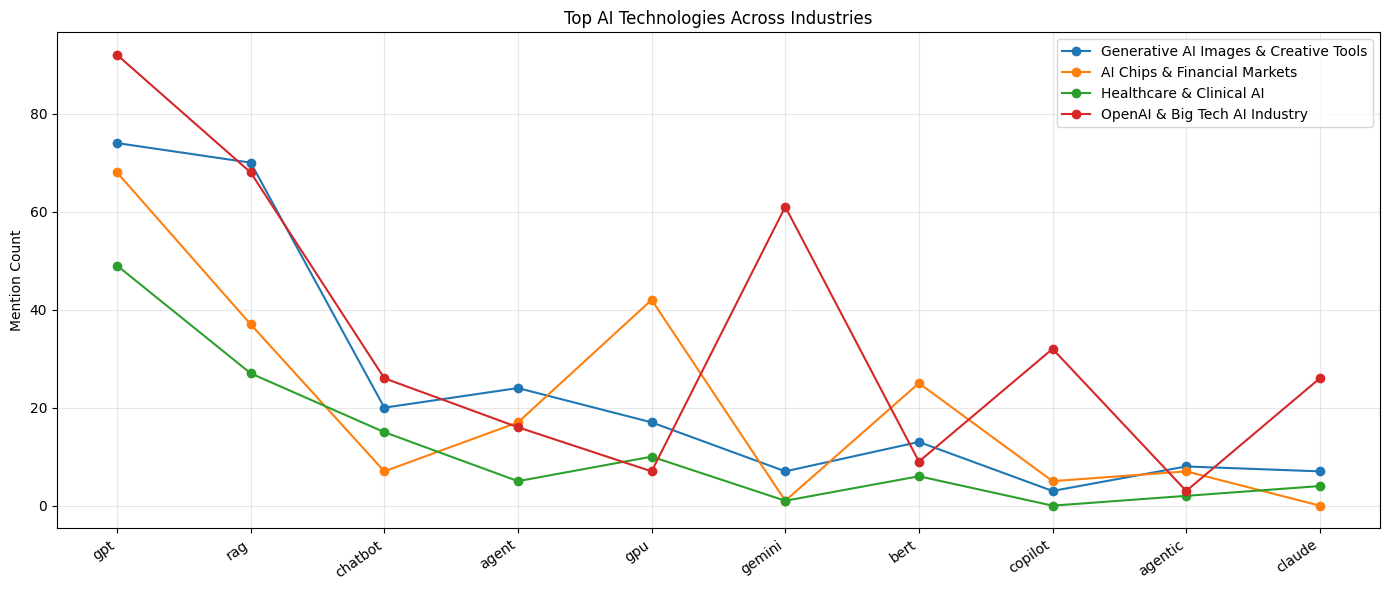

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# =========================
# 1) Ensure tech_terms is a list (CSV stores lists as strings)
# =========================
import ast

def to_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or str(x).strip() == "":
        return []
    s = str(x).strip()
    # try parse like "['gpt','rag']"
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else []
    except Exception:
        # fallback: split on commas
        return [t.strip() for t in s.split(",") if t.strip()]

df_model["tech_terms"] = df_model["tech_terms"].apply(to_list)

# normalize text (optional)
df_model["tech_terms"] = df_model["tech_terms"].apply(lambda lst: [str(t).strip().lower() for t in lst if str(t).strip()])

# =========================
# 2) Filter industries + explode into long format
# =========================
NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}
df_use = df_model[~df_model["industry"].isin(NOISE_INDUSTRIES)].copy()

tech_long = (
    df_use[["industry", "tech_terms"]]
    .explode("tech_terms")
    .rename(columns={"tech_terms": "technology"})
)
tech_long["technology"] = tech_long["technology"].fillna("").astype(str).str.strip()
tech_long = tech_long[tech_long["technology"] != ""]

# =========================
# 3) Pick top industries + top technologies
# =========================
top_industries = (
    df_use["industry"]
    .value_counts()
    .head(4)
    .index
    .tolist()
)
print("Top industries:", top_industries)

top_tech = (
    tech_long["technology"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)
print("Top technologies:", top_tech)

# =========================
# 4) Pivot (x=technology names, y=counts, line=industry)
# =========================
tech_pivot = (
    tech_long[tech_long["technology"].isin(top_tech) & tech_long["industry"].isin(top_industries)]
    .groupby(["industry", "technology"])
    .size()
    .reset_index(name="mention_count")
    .pivot(index="technology", columns="industry", values="mention_count")
    .fillna(0)
)

# keep only your industries in a consistent order + keep tech order
tech_pivot = tech_pivot.reindex(top_tech)         # x-axis order
tech_pivot = tech_pivot[top_industries]           # line order

# =========================
# 5) Plot (like your screenshot)
# =========================
plt.figure(figsize=(14, 6))

for ind in top_industries:
    plt.plot(tech_pivot.index, tech_pivot[ind], marker="o", label=ind)

plt.xticks(rotation=35, ha="right")
plt.ylabel("Mention Count")
plt.title("Top AI Technologies Across Industries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top industries: ['Generative AI Images & Creative Tools', 'AI Chips & Financial Markets', 'Healthcare & Clinical AI', 'OpenAI & Big Tech AI Industry']


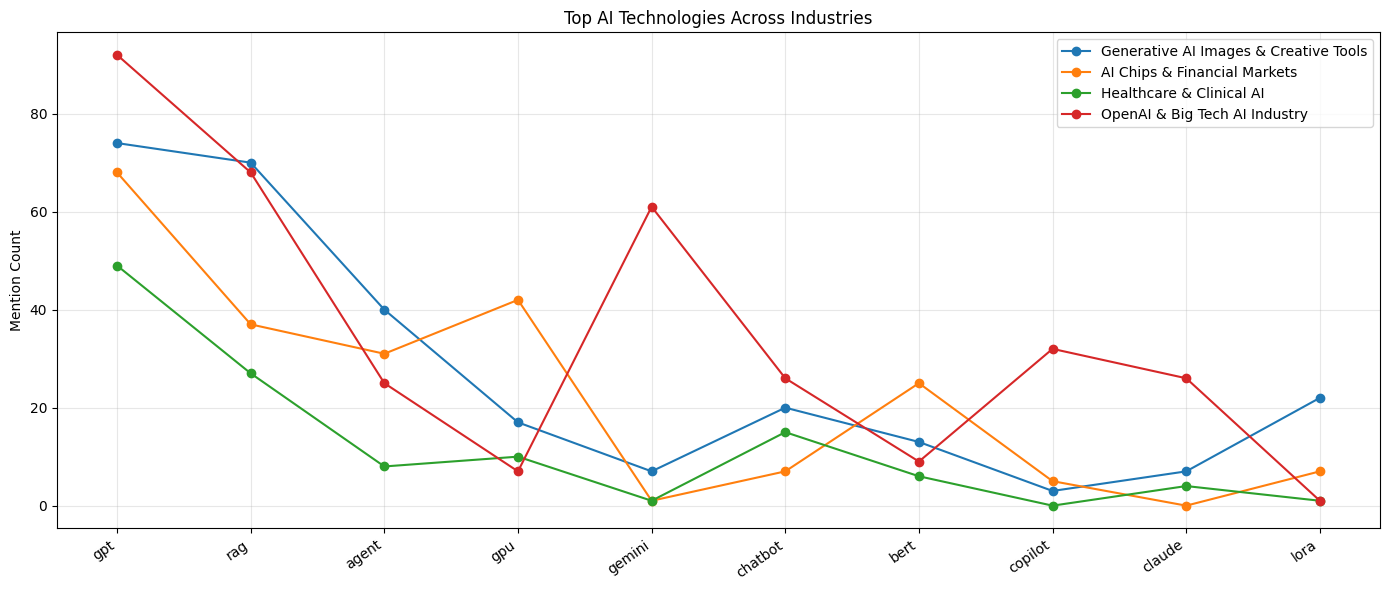

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Assumes df_model already exists and includes:
#    - df_model["industry"] (string)
#    - df_model["tech_terms"] (list of strings per row)
#    - top_industries (list of 4 industries) OR we compute it below
# ============================================================

# ----------------------------
# 1) Optional: filter noise industries
# ----------------------------
NOISE_INDUSTRIES = {
    "Outlier / Unclustered",
    "Other / Mixed",
    "Newswire / Distribution (noise)",
    "Broadcast / Radio / Programming (noise)",
    "Non-English / Mixed (noise)",
    "Entertainment / Media (noise)",
    "Local News / Weather (noise)",
}

df_use = df_model.copy()
if "industry" in df_use.columns:
    df_use = df_use[~df_use["industry"].isin(NOISE_INDUSTRIES)].copy()

# ----------------------------
# 2) Normalize / merge technology variants
#    - combines agent + agentic + agents -> agent
#    - also includes a few helpful merges (optional but clean)
# ----------------------------
def normalize_tech(term: str) -> str:
    t = str(term).lower().strip()
    t = re.sub(r"\s+", " ", t)

    # merge agent variants
    if t in {"agent", "agents", "agentic"}:
        return "agent"

    # merge LLM variants
    if t in {"llm", "llms", "large language model", "large language models"}:
        return "llm"

    # merge GPT variants
    if t in {"chatgpt", "gpt-3", "gpt-3.5", "gpt-4", "gpt3", "gpt4"}:
        return "gpt"

    # merge diffusion variants
    if t in {"stable diffusion", "stablediffusion", "diffusion"}:
        return "diffusion"

    # merge RAG variants
    if t in {"rag", "retrieval augmented generation", "retrieval-augmented generation"}:
        return "rag"

    return t

# ensure tech_terms exists
if "tech_terms" not in df_use.columns:
    raise KeyError(f"df_model is missing 'tech_terms'. Current cols: {df_model.columns.tolist()}")

# apply normalization
df_use["tech_terms"] = df_use["tech_terms"].apply(
    lambda lst: [normalize_tech(x) for x in (lst if isinstance(lst, list) else [])]
)

# ----------------------------
# 3) Pick top 4 industries (if you haven't already)
# ----------------------------
if "top_industries" not in globals():
    top_industries = df_use["industry"].value_counts().head(4).index.tolist()
print("Top industries:", top_industries)

# ----------------------------
# 4) Build long table for tech
# ----------------------------
tech_long = (
    df_use[["industry", "tech_terms"]]
    .explode("tech_terms")
    .rename(columns={"tech_terms": "technology"})
)

tech_long["technology"] = tech_long["technology"].fillna("").astype(str).str.strip()
tech_long = tech_long[tech_long["technology"] != ""]

# ----------------------------
# 5) Choose Top 10 technologies overall (across selected industries)
# ----------------------------
top_tech = (
    tech_long[tech_long["industry"].isin(top_industries)]["technology"]
    .value_counts()
    .head(10)
    .index.tolist()
)

# ----------------------------
# 6) Pivot: x-axis = technology names, lines = industries
# ----------------------------
tech_pivot = (
    tech_long[
        tech_long["industry"].isin(top_industries) &
        tech_long["technology"].isin(top_tech)
    ]
    .groupby(["industry", "technology"])
    .size()
    .reset_index(name="mention_count")
    .pivot(index="technology", columns="industry", values="mention_count")
    .fillna(0)
)

# keep column order = top_industries
tech_pivot = tech_pivot.reindex(columns=top_industries)

# order x-axis by overall frequency
tech_order = tech_pivot.sum(axis=1).sort_values(ascending=False).index
tech_pivot = tech_pivot.reindex(index=tech_order)

# ----------------------------
# 7) Plot line chart
# ----------------------------
plt.figure(figsize=(14, 6))
for ind in top_industries:
    plt.plot(tech_pivot.index, tech_pivot[ind].values, marker="o", label=ind)

plt.xticks(rotation=35, ha="right")
plt.ylabel("Mention Count")
plt.title("Top AI Technologies Across Industries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()